# 4.0 Model training - LightGBM


## Imports


In [1]:
import numpy as np
import pandas as pd
import joblib
import json
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL,
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    light_gbm_gridsearch,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred, plot_feature_importances
from recruit_restaurant_visitor_forecasting.utils import merge_daily_pred, convert_to_serializable, get_format
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2026-01-02 16:16:26.047 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
CV_SPLITS = 3
TEST_SIZE = 0.2
DROP_COLUMNS = [AIR_RESTAURANT_ID_COL, VISIT_DATE_COL, VISITORS_NBR_COL, DAY_OF_WEEK_COL, CITY_COL]

MODEL_PATH = MODELS_DIR / "lightgbm_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")

Features shape: (271221, 50)
Labels shape: (271221,)


In [4]:
original_index = features.index.copy()
features = prepare_features(features)

labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [5]:
X = features
y = labels

In [6]:
X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


## Training


In [7]:
grid_search = light_gbm_gridsearch(verbose=3, n_jobs=-1, drop_features=DROP_COLUMNS, n_splits=CV_SPLITS)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Fitting 3 folds for each of 1296 candidates, totalling 3888 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024222 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9079
[LightGBM] [Info] Number of data points in the train set: 197104, number of used features: 45
[LightGBM] [Info] Start training from score 17.605584
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [10]:
pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score").head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__colsample_bytree,param_model__learning_rate,param_model__max_depth,param_model__min_child_samples,param_model__n_estimators,param_model__num_leaves,param_model__reg_alpha,param_model__reg_lambda,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
1258,13.569206,0.766752,0.007512,0.000384,1.0,0.1,7,20,200,63,1.0,0.1,"{'model__colsample_bytree': 1.0, 'model__learn...",-0.618345,-0.606180,-0.760712,-0.661745,0.070156,1
568,12.326828,0.787683,0.007428,0.000223,0.8,0.1,7,10,200,63,0.0,0.1,"{'model__colsample_bytree': 0.8, 'model__learn...",-0.628076,-0.608759,-0.752261,-0.663032,0.063585,2
574,13.344545,0.187278,0.007804,0.000932,0.8,0.1,7,10,200,63,1.0,0.1,"{'model__colsample_bytree': 0.8, 'model__learn...",-0.622253,-0.613725,-0.754028,-0.663335,0.064224,3
611,14.847014,0.353179,0.008007,0.000694,0.8,0.1,7,20,200,63,1.0,1.0,"{'model__colsample_bytree': 0.8, 'model__learn...",-0.618707,-0.615097,-0.758486,-0.664097,0.066759,4
575,13.705897,0.398430,0.007332,0.000115,0.8,0.1,7,10,200,63,1.0,1.0,"{'model__colsample_bytree': 0.8, 'model__learn...",-0.618219,-0.608230,-0.765896,-0.664115,0.072086,5


In [11]:
model = grid_search.best_estimator_
y_train_pred = model.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")
print(f"R2:   {train_r2:.4f}")

Train set metrics:
RMSLE: 0.8092
MAE:  6.2672
R2:   0.6857


In [14]:
y_test_pred, temp_features = recursive_predict(
    model,
    X_test,
    X_train,
    y_train,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively:   0%|          | 0/90 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.95379061e+01 1.27922626e+01 7.88520946e+00 4.31475169e+00
 4.13901397e+00 1.89897156e+01 1.20185807e+01 3.98655370e+01
 3.08928774e+01 7.57490562e+00 2.90278103e+01 3.18179333e+00
 1.82568629e+01 3.14894529e+01 1.32862586e+01 9.22935334e+00
 4.78428518e-01 6.74744367e+00 2.39514745e+00 2.71252061e+01
 2.30495577e+01 3.73196100e+01 6.16362307e+00 1.00695990e+01
 9.87558079e+00 1.30868976e+01 4.05790419e+00 8.70839247e+00
 6.88105194e+00 2.44447867e+01 0.00000000e+00 4.45613605e+01
 2.40414457e+01 5.98324362e+00 3.73649853e-01 2.78919974e+01
 8.67379880e+00 2.62017265e+00 1.06307253e+01 9.66710471e+00
 1.42704103e+00 6.06244758e+00 1.53944294e+01 5.35585336e+00
 3.21713483e-01 1.83320327e+01 8.51616052e+00 4.61145

In [15]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R2:   {test_r2:.4f}")


Test set metrics:
RMSLE: 0.8253
MAE:  7.0132
R2:   0.5648


## Graphs

### Feature importances

<Figure size 1200x1000 with 0 Axes>

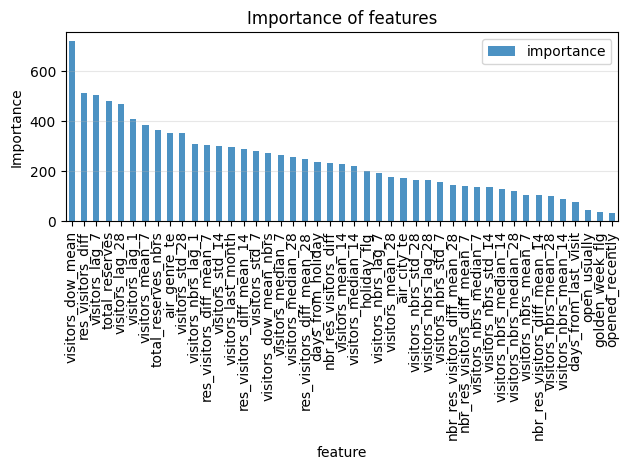

In [10]:
plot_feature_importances(model, X.columns.drop(DROP_COLUMNS))

### Visitors per day: actual vs predicted

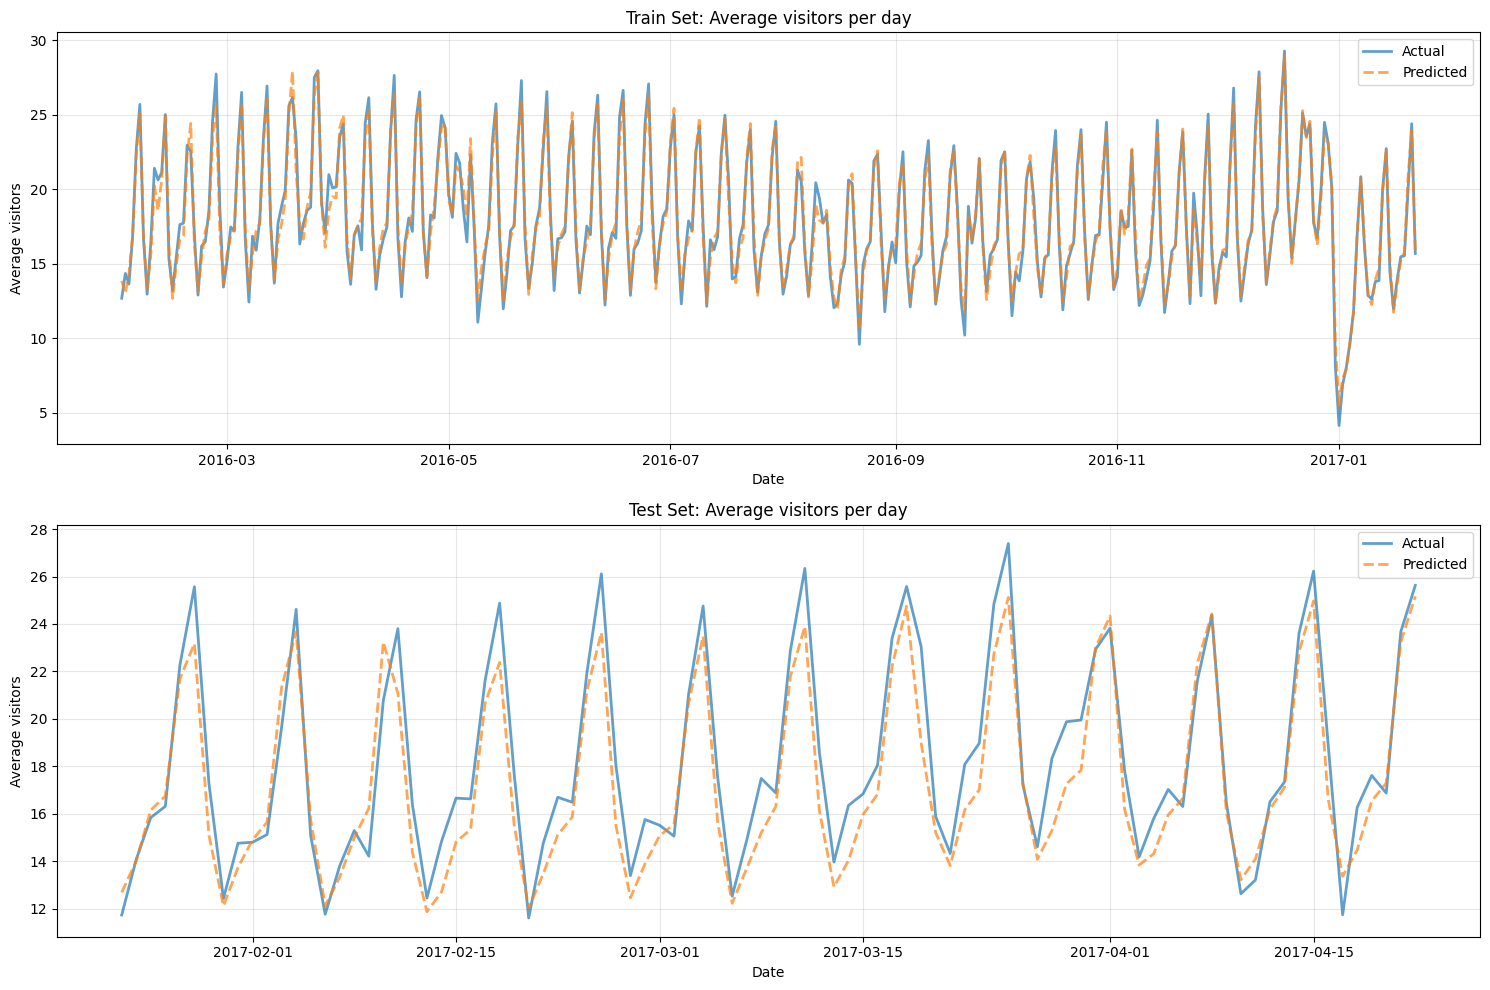

In [16]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [7]:
model = joblib.load(MODEL_PATH)

In [17]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)

In [18]:
test_labels, temp_features = recursive_predict(
    model,
    test_features,
    X,
    y,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively:   0%|          | 0/39 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[8.37109180e-01 3.37248204e-01 1.03479339e+01 4.61913489e+00
 2.57255563e+01 2.44264685e+01 2.66304582e+01 0.00000000e+00
 3.81849941e+01 1.75945609e+00 2.07324722e+01 4.66859705e+00
 2.73439303e+01 4.88731527e+01 2.38031978e+01 4.88283135e+00
 1.37481231e+01 1.15919158e+01 2.18970885e+01 5.16956968e+01
 5.73355060e+00 1.47841959e+01 1.43137226e+01 1.73611958e+01
 1.18424672e+00 3.00433979e+01 1.20250116e+01 2.23104833e+01
 7.80323992e-01 1.26528850e+01 2.12320051e+01 3.69215266e+00
 1.75362835e+01 9.64891485e+00 7.78135746e+00 0.00000000e+00
 1.27626680e+00 3.37576768e+01 2.05661007e+01 1.26103780e+01
 3.62562838e+01 3.65576604e+01 5.32703168e+00 7.86164364e-01
 1.58474846e+01 1.54115822e+01 1.91655124e+00 1.17306

In [19]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [13]:
joblib.dump(model, MODEL_PATH)

params_to_save = {
    "best_params": convert_to_serializable(grid_search.best_params_),
    "best_score": float(grid_search.best_score_),
}

params_path = MODELS_DIR / "lightgbm_model_params.json"
with open(params_path, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)